In [1]:
import os, sys
import pandas as pd
import scanpy as sc
import anndata as ad

In [2]:
os.chdir('/Users/stanleydale/user_generated/Work/breault-lab/imac-single-cell/input-data')

### Start with the day 2 data, + lapatinib

In [3]:
d2_dz = sc.read_h5ad("clustered_egfDuod_D2_DZ.h5ad")

In [4]:
d2_dz.obs["leiden"].dtype

CategoricalDtype(categories=['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11',
                  '12', '13', '14', '15', '16', '17', '18', '19', '20', '21',
                  '22', '23'],
, ordered=False, categories_dtype=object)

In [5]:
### Create a map of the new labels 

# For D2 Dz
d2_dz_map = {
    "0": "ISCs",
    "1": "ISCs",
    "2": "Proliferating progenitor cells",
    # If I decide cluster 4 is secretory progenitors, change this line:
    "4": "Enterocytes",
}



In [6]:
## Initialise a new slot in the scanpy object .obs

d2_dz.obs["manual_label"] = "Unlabeled"

In [7]:
for cl, lab in d2_dz_map.items():
    sel = d2_dz.obs["leiden"] == cl
    d2_dz.obs.loc[sel, "manual_label"] = lab

In [8]:
d2_dz.obs["manual_label"].head

<bound method NDFrame.head of AAACCAAAGATACTCG-1                         Unlabeled
AAACCAAAGCCAACTA-1    Proliferating progenitor cells
AAACCAAAGGCACACT-1    Proliferating progenitor cells
AAACCAAAGGTGCTCG-1                       Enterocytes
AAACCAAAGTCAACTG-1                         Unlabeled
                                   ...              
TGTGTTGAGGTATAGA-1                              ISCs
TGTGTTGAGTAATCAC-1                              ISCs
TGTGTTGAGTAGTTCG-1                              ISCs
TGTGTTGAGTCGCGTG-1    Proliferating progenitor cells
TGTGTTGAGTGAGTAA-1                              ISCs
Name: manual_label, Length: 46210, dtype: object>

In [9]:
d2_dz.obs

,orig.ident,nCount_RNA,nFeature_RNA,freemuxlet.identity,participant,Condition,Time_point,Treatment,ident,leiden,manual_label
AAACCAAAGATACTCG-1,D2,836.0,665,Negative,Negative,G2D2,G2D2,Untreated,D2,11,Unlabeled
AAACCAAAGCCAACTA-1,D2,4748.0,2337,2,H897,G2D2,G2D2,Untreated,D2,2,Proliferating progenitor cells
AAACCAAAGGCACACT-1,D2,3957.0,1911,2,H897,G2D2,G2D2,Untreated,D2,2,Proliferating progenitor cells
AAACCAAAGGTGCTCG-1,D2,4934.0,2292,1,H896,G2D2,G2D2,Untreated,D2,4,Enterocytes
AAACCAAAGTCAACTG-1,D2,10380.0,3749,1,H896,G2D2,G2D2,Untreated,D2,5,Unlabeled
...,...,...,...,...,...,...,...,...,...,...,...
TGTGTTGAGGTATAGA-1,D2,7473.0,3086,0,H329,G2D2,G2D2,Untreated,D2,1,ISCs
TGTGTTGAGTAATCAC-1,D2,10060.0,3149,0,H329,G2D2,G2D2,Untreated,D2,1,ISCs
TGTGTTGAGTAGTTCG-1,D2,9850.0,3346,0,H329,G2D2,G2D2,Untreated,D2,1,ISCs
TGTGTTGAGTCGCGTG-1,D2,3967.0,2007,0,H329,G2D2,G2D2,Untreated,D2,2,Proliferating progenitor cells


### Let's now include our + Lapatinib data

In [10]:
d2_lapa = sc.read_h5ad("clustered_egfDuod_D2_Lapa_DZ.h5ad")

In [11]:
d2_lapa.obs

,orig.ident,nCount_RNA,nFeature_RNA,freemuxlet.identity,participant,Condition,Time_point,Treatment,ident,leiden
AAACCAAAGAAGCACG-1,D2_Lapa,2129.0,1242,1,H329,G2D2_Lapa,G2D2,Lapa,D2_Lapa,4
AAACCAAAGATAGGGT-1,D2_Lapa,3418.0,1867,0,H896,G2D2_Lapa,G2D2,Lapa,D2_Lapa,1
AAACCAAAGATTACCG-1,D2_Lapa,1838.0,1204,0,H896,G2D2_Lapa,G2D2,Lapa,D2_Lapa,0
AAACCAAAGCCACTAA-1,D2_Lapa,18366.0,4900,2,H439,G2D2_Lapa,G2D2,Lapa,D2_Lapa,2
AAACCAAAGCCAGTGT-1,D2_Lapa,2272.0,1408,2,H439,G2D2_Lapa,G2D2,Lapa,D2_Lapa,0
...,...,...,...,...,...,...,...,...,...,...
TGTGTTGAGTCAGTGC-1,D2_Lapa,4107.0,2378,1,H329,G2D2_Lapa,G2D2,Lapa,D2_Lapa,11
TGTGTTGAGTGCCCGA-1,D2_Lapa,2812.0,1785,Doublet,Doublet,G2D2_Lapa,G2D2,Lapa,D2_Lapa,3
TGTGTTGAGTGGCTGT-1,D2_Lapa,7844.0,2781,1,H329,G2D2_Lapa,G2D2,Lapa,D2_Lapa,4
TGTGTTGAGTTACACG-1,D2_Lapa,1207.0,858,Doublet,Doublet,G2D2_Lapa,G2D2,Lapa,D2_Lapa,1


In [12]:
d2_lapa.obs["participant"].unique

<bound method Series.unique of AAACCAAAGAAGCACG-1       H329
AAACCAAAGATAGGGT-1       H896
AAACCAAAGATTACCG-1       H896
AAACCAAAGCCACTAA-1       H439
AAACCAAAGCCAGTGT-1       H439
                       ...   
TGTGTTGAGTCAGTGC-1       H329
TGTGTTGAGTGCCCGA-1    Doublet
TGTGTTGAGTGGCTGT-1       H329
TGTGTTGAGTTACACG-1    Doublet
TGTGTTGAGTTGCTTC-1       H439
Name: participant, Length: 60337, dtype: category
Categories (5, object): ['Doublet', 'H329', 'H439', 'H896', 'Negative']>

In [13]:
d2_dz.obs["participant"].unique()

['Negative', 'H897', 'H896', 'H329', 'Doublet']
Categories (5, object): ['Doublet', 'H329', 'H896', 'H897', 'Negative']

In [14]:
### We will proceed with using the "Condition", and the ["participant"] slots in the obs metadata for specifying our pseudobulk. First, we need to concatenate our data

In [15]:
#### Let's concatenate our data

In [16]:
#d2_combined = ad.concat(
#    {"D2_Dz": d2_dz, "D2_Lapa": d2_lapa},
#    label="dataset",
#    join="outer",
#    index_unique=None,
#)


In [17]:
## Let's drop the sample ids that aren't useful

import pandas as pd
from scipy.sparse import issparse

# drop non-donors
bad_participants = ["Doublet", "Negative"]
d2_dz = d2_dz[
    ~d2_dz.obs["participant"].isin(bad_participants),
].copy()

# make an explicit sample_id = participant
d2_dz.obs["sample_id"] = d2_dz.obs["participant"].astype(str)


In [18]:
cell_type = "ISCs"
sub = d2_dz[d2_dz.obs["manual_label"] == cell_type].copy()
sub.obs["sample_id"] = sub.obs["participant"].astype(str)
sub.obs["pb_id"] = (
    sub.obs["sample_id"].astype(str)
    + "_"
    + sub.obs["Condition"].astype(str)
)


In [19]:
sub

AnnData object with n_obs × n_vars = 18479 × 27844
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident', 'leiden', 'manual_label', 'sample_id', 'pb_id'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'X_name', 'hvg'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [20]:
from scipy.sparse import issparse

# 1. Get the counts matrix from the 'counts' layer
counts = sub.layers["counts"]



if issparse(counts):
    counts = counts.tocsr()

# Sanity-check dimensions against AnnData
n_cells, n_genes = sub.n_obs, sub.n_vars
print("counts.shape:", counts.shape)
print("expected:", (n_cells, n_genes))

# If the matrix is transposed (genes x cells), fix it
if counts.shape == (n_genes, n_cells):
    counts = counts.T

# 2. Build a sparse DataFrame: rows = cells, cols = genes
counts_df = pd.DataFrame.sparse.from_spmatrix(
    counts,
    index=sub.obs_names,   # one row per cell
    columns=sub.var_names, # one column per gene
)

print("counts_df.shape:", counts_df.shape)

counts.shape: (18479, 27844)
expected: (18479, 27844)
counts_df.shape: (18479, 27844)


In [21]:
# 3. Sum over cells with the same pb_id → pseudobulk samples
pb_counts = counts_df.groupby(sub.obs["pb_id"]).sum()  # samples x genes
print("pb_counts shape (samples x genes):", pb_counts.shape)

# 4. Transpose to genes x samples (what we usually want before filtering)
pb_counts = pb_counts.T
print("pb_counts shape (genes x samples):", pb_counts.shape)


pb_counts shape (samples x genes): (3, 27844)
pb_counts shape (genes x samples): (27844, 3)


In [22]:
pb_counts

pb_id,H329_G2D2,H896_G2D2,H897_G2D2
MIR1302-2HG,1.0,0,0
AL627309.1,26.0,33.0,4.0
AL627309.3,2.0,0,0
AL627309.5,52.0,60.0,11.0
LINC01409,299.0,279.0,91.0
...,...,...,...
AC004556.3,11.0,209.0,3.0
AC136352.3,4.0,1.0,1.0
AC136616.1,0,0,0
AC007325.4,29.0,26.0,9.0


In [23]:
pb_counts.to_csv("/Users/stanleydale/user_generated/Work/breault-lab/imac-single-cell/pydeseq-input/pb_counts_iscs.csv")

## Repeat for the Lapatinib data, before we then merge the pd data

In [24]:
del d2_dz

In [25]:
d2_lapa_map = {
    "1": "ISCs",
    "0": "PCs",
    "4": "Proliferating progenitor cells",
    "2": "Secretory progenitor cells",
    "3": "Enterocytes",
    "20": "Goblet cells",
}


In [26]:
d2_lapa.obs["manual_label"] = "Unlabeled"
for cl, lab in d2_lapa_map.items():
    sel = d2_lapa.obs["leiden"] == cl
    d2_lapa.obs.loc[sel, "manual_label"] = lab

In [27]:
bad_participants = ["Doublet", "Negative"]
d2_lapa = d2_lapa[
    ~d2_lapa.obs["participant"].isin(bad_participants),
].copy()

d2_lapa.obs["sample_id"] = d2_lapa.obs["participant"].astype(str)

In [28]:
cell_type = "ISCs"
sub = d2_lapa[d2_lapa.obs["manual_label"] == cell_type].copy()
sub.obs["sample_id"] = sub.obs["participant"].astype(str)
sub.obs["pb_id"] = (
    sub.obs["sample_id"].astype(str)
    + "_"
    + sub.obs["Condition"].astype(str)
)


In [29]:
from scipy.sparse import issparse

# 1. Get the counts matrix from the 'counts' layer
counts = sub.layers["counts"]



if issparse(counts):
    counts = counts.tocsr()

# Sanity-check dimensions against AnnData
n_cells, n_genes = sub.n_obs, sub.n_vars
print("counts.shape:", counts.shape)
print("expected:", (n_cells, n_genes))

# If the matrix is transposed (genes x cells), fix it
if counts.shape == (n_genes, n_cells):
    counts = counts.T

# 2. Build a sparse DataFrame: rows = cells, cols = genes
counts_df = pd.DataFrame.sparse.from_spmatrix(
    counts,
    index=sub.obs_names,   # one row per cell
    columns=sub.var_names, # one column per gene
)

print("counts_df.shape:", counts_df.shape)

counts.shape: (9192, 28941)
expected: (9192, 28941)
counts_df.shape: (9192, 28941)


In [30]:
counts_df

,AL627309.1,AL627309.5,AL627309.4,AP006222.2,LINC01409,FAM87B,LINC01128,LINC00115,FAM41C,AL645608.6,...,AC011043.1,AC011043.2,AC011841.1,AL354822.1,AL592183.1,AC240274.1,AC004556.3,AC136352.3,AC007325.4,AC007325.2
AAACCAAAGATAGGGT-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AAACCAAAGCTGGAAG-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AAACCAAAGGGTCTAC-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AAACCATTCCATGTGA-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AAACCATTCGTCTCCA-1,0,0,0,0,1.0,0,0,0,0,0,...,0,0,0,0,1.0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TGTGTTAGTTGAAGTG-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TGTGTTAGTTTCAGGT-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TGTGTTGAGGGCTCAT-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1.0,0,0,0,0
TGTGTTGAGTAGCCAC-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [31]:
# 3. Sum over cells with the same pb_id → pseudobulk samples
pb_counts = counts_df.groupby(sub.obs["pb_id"]).sum()  # samples x genes
print("pb_counts shape (samples x genes):", pb_counts.shape)

# 4. Transpose to genes x samples (what we usually want before filtering)
pb_counts = pb_counts.T
print("pb_counts shape (genes x samples):", pb_counts.shape)


pb_counts shape (samples x genes): (3, 28941)
pb_counts shape (genes x samples): (28941, 3)


In [32]:
pb_counts

pb_id,H329_G2D2_Lapa,H439_G2D2_Lapa,H896_G2D2_Lapa
AL627309.1,15.0,6.0,3.0
AL627309.5,24.0,10.0,7.0
AL627309.4,0,0,1.0
AP006222.2,0,0,0
LINC01409,204.0,110.0,77.0
...,...,...,...
AC240274.1,97.0,36.0,28.0
AC004556.3,3.0,0,50.0
AC136352.3,1.0,0,0
AC007325.4,28.0,13.0,5.0


### Merge the pseudobulk dataframes

In [33]:
original_pb = pd.read_csv("/Users/stanleydale/user_generated/Work/breault-lab/imac-single-cell/pydeseq-input/pb_counts_iscs.csv", index_col=0)

In [34]:
original_pb

,H329_G2D2,H896_G2D2,H897_G2D2
MIR1302-2HG,1.0,0.0,0.0
AL627309.1,26.0,33.0,4.0
AL627309.3,2.0,0.0,0.0
AL627309.5,52.0,60.0,11.0
LINC01409,299.0,279.0,91.0
...,...,...,...
AC004556.3,11.0,209.0,3.0
AC136352.3,4.0,1.0,1.0
AC136616.1,0.0,0.0,0.0
AC007325.4,29.0,26.0,9.0


In [35]:
pb_counts

pb_id,H329_G2D2_Lapa,H439_G2D2_Lapa,H896_G2D2_Lapa
AL627309.1,15.0,6.0,3.0
AL627309.5,24.0,10.0,7.0
AL627309.4,0,0,1.0
AP006222.2,0,0,0
LINC01409,204.0,110.0,77.0
...,...,...,...
AC240274.1,97.0,36.0,28.0
AC004556.3,3.0,0,50.0
AC136352.3,1.0,0,0
AC007325.4,28.0,13.0,5.0


In [36]:
pb_counts = pb_counts.set_index("pb_id")
pb_counts.head()

KeyError: "None of ['pb_id'] are in the columns"

In [ ]:
df_combined = pd.concat([original_pb, pb_counts], axis=1)


In [ ]:
df_combined

,H329_G2D2,H896_G2D2,H897_G2D2,H329_G2D2_Lapa,H439_G2D2_Lapa,H896_G2D2_Lapa
MIR1302-2HG,1.0,0.0,0.0,NaN,NaN,NaN
AL627309.1,26.0,33.0,4.0,15.0,6.0,3.0
AL627309.3,2.0,0.0,0.0,NaN,NaN,NaN
AL627309.5,52.0,60.0,11.0,24.0,10.0,7.0
LINC01409,299.0,279.0,91.0,204.0,110.0,77.0
...,...,...,...,...,...,...
FATE1,NaN,NaN,NaN,0,0,0
ATP2B3,NaN,NaN,NaN,0,0,0
HCFC1-AS1,NaN,NaN,NaN,0,0,0
OPN1MW,NaN,NaN,NaN,0,0,0


In [ ]:
df_combined.to_csv("/Users/stanleydale/user_generated/Work/breault-lab/imac-single-cell/pydeseq-input/df_combined_iscs.csv")

In [ ]:
df_combined = pd.read_csv("/Users/stanleydale/user_generated/Work/breault-lab/imac-single-cell/pydeseq-input/df_combined_iscs.csv", index_col=0)

In [ ]:
df_combined

,H329_G2D2,H896_G2D2,H897_G2D2,H329_G2D2_Lapa,H439_G2D2_Lapa,H896_G2D2_Lapa
MIR1302-2HG,1.0,0.0,0.0,NaN,NaN,NaN
AL627309.1,26.0,33.0,4.0,15.0,6.0,3.0
AL627309.3,2.0,0.0,0.0,NaN,NaN,NaN
AL627309.5,52.0,60.0,11.0,24.0,10.0,7.0
LINC01409,299.0,279.0,91.0,204.0,110.0,77.0
...,...,...,...,...,...,...
FATE1,NaN,NaN,NaN,0.0,0.0,0.0
ATP2B3,NaN,NaN,NaN,0.0,0.0,0.0
HCFC1-AS1,NaN,NaN,NaN,0.0,0.0,0.0
OPN1MW,NaN,NaN,NaN,0.0,0.0,0.0


#### We need to transpose the matrix, and create a metadata df, fort pydeseq2

In [ ]:
df_clean = df_combined.fillna(0)
df_clean = df_clean.astype(int)


In [ ]:
counts_df = df_clean.T   # now: rows = samples, cols = genes
counts_df.shape


(6, 29512)

In [ ]:
samples = counts_df.index

condition = ["Lapa" if "Lapa" in s else "Dz" for s in samples]
participant = [s.split("_")[0] for s in samples]

clinical_df = pd.DataFrame(
    {
        "condition": condition,
        "participant": participant,
    },
    index=samples,   # IMPORTANT: index must match counts_df.index
)

clinical_df


,condition,participant
H329_G2D2,Dz,H329
H896_G2D2,Dz,H896
H897_G2D2,Dz,H897
H329_G2D2_Lapa,Lapa,H329
H439_G2D2_Lapa,Lapa,H439
H896_G2D2_Lapa,Lapa,H896


### Run pydeseq2

In [ ]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

# create DESeq dataset
dds = DeseqDataSet(
    counts=counts_df,
    metadata=clinical_df,
    design_factors="condition",  # use the 'condition' column
)

# fit dispersions + LFCs
dds.deseq2()

# compare Lapa vs Dz
stats = DeseqStats(
    dds,
    contrast=["condition", "Lapa", "Dz"],  # tested_level, reference_level
)

stats.summary()
res = stats.results_df
res.head()


Using None as control genes, passed at DeseqDataSet initialization


/var/folders/h4/gmb18r416rs2h3sdc7knc0500000gn/T/ipykernel_21384/2528878090.py:5: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 1.14 seconds.

Fitting dispersion trend curve...
... done in 0.20 seconds.

Fitting MAP dispersions...
... done in 1.31 seconds.

Fitting LFCs...
... done in 1.02 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...


Log2 fold change & Wald test p-value: condition Lapa vs Dz
               baseMean  log2FoldChange     lfcSE      stat    pvalue  \
MIR1302-2HG    0.060308        0.376696  4.471134  0.084251  0.932857   
AL627309.1    10.266478        0.062183  0.643138  0.096687  0.922975   
AL627309.3     0.120616       -0.277962  4.384783 -0.063393  0.949454   
AL627309.5    19.867248       -0.147538  0.466439 -0.316308  0.751769   
LINC01409    157.294418        0.591651  0.220010  2.689196  0.007162   
...                 ...             ...       ...       ...       ...   
FATE1          0.000000             NaN       NaN       NaN       NaN   
ATP2B3         0.000000             NaN       NaN       NaN       NaN   
HCFC1-AS1      0.000000             NaN       NaN       NaN       NaN   
OPN1MW         0.000000             NaN       NaN       NaN       NaN   
TEX28          0.157022        2.200541  4.464610  0.492885  0.622094   

                 padj  
MIR1302-2HG       NaN  
AL627309.1   0.9

... done in 0.49 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
MIR1302-2HG,0.060308,0.376696,4.471134,0.084251,0.932857,NaN
AL627309.1,10.266478,0.062183,0.643138,0.096687,0.922975,0.966776
AL627309.3,0.120616,-0.277962,4.384783,-0.063393,0.949454,NaN
AL627309.5,19.867248,-0.147538,0.466439,-0.316308,0.751769,0.887937
LINC01409,157.294418,0.591651,0.220010,2.689196,0.007162,0.046789


### Let's plot a volcano plot

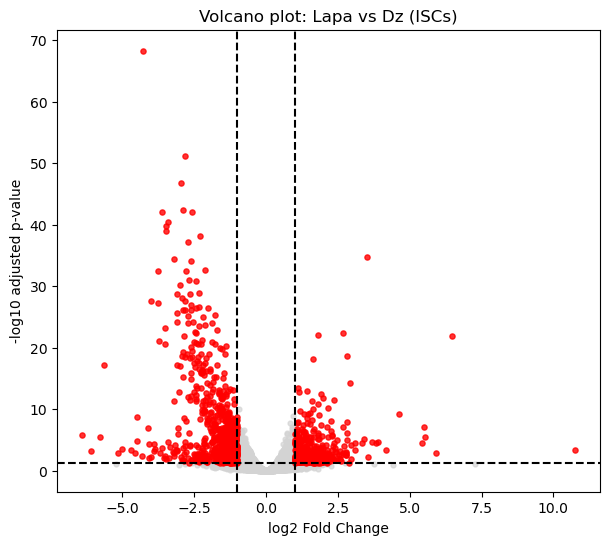

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = res.copy()

df["-log10padj"] = -np.log10(df["padj"])

plt.figure(figsize=(7,6))

# Color significant vs not
sig = (df["padj"] < 0.05) & (abs(df["log2FoldChange"]) > 1)

plt.scatter(
    df.loc[~sig, "log2FoldChange"],
    df.loc[~sig, "-log10padj"],
    color="lightgray",
    alpha=0.7,
    s=12,
)

plt.scatter(
    df.loc[sig, "log2FoldChange"],
    df.loc[sig, "-log10padj"],
    color="red",
    alpha=0.8,
    s=14,
)

# Significance thresholds
plt.axhline(-np.log10(0.05), linestyle="--", color="black")
plt.axvline(1, linestyle="--", color="black")
plt.axvline(-1, linestyle="--", color="black")

plt.xlabel("log2 Fold Change")
plt.ylabel("-log10 adjusted p-value")
plt.title("Volcano plot: Lapa vs Dz (ISCs)")
plt.show()


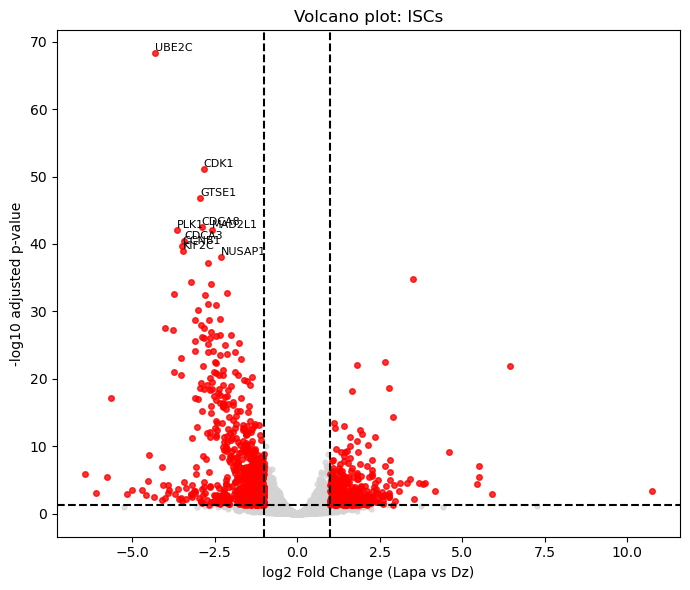

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

df = res.copy()
df = df.dropna(subset=["log2FoldChange", "padj"])
df["-log10padj"] = -np.log10(df["padj"])

# significance definition
sig = (df["padj"] < 0.05) & (df["log2FoldChange"].abs() > 1)

plt.figure(figsize=(7,6))

# non-significant points
plt.scatter(
    df.loc[~sig, "log2FoldChange"],
    df.loc[~sig, "-log10padj"],
    color="lightgray",
    alpha=0.7,
    s=12,
)

# significant points
plt.scatter(
    df.loc[sig, "log2FoldChange"],
    df.loc[sig, "-log10padj"],
    color="red",
    alpha=0.8,
    s=16,
)

# thresholds
plt.axhline(-np.log10(0.05), linestyle="--", color="black")
plt.axvline(1, linestyle="--", color="black")
plt.axvline(-1, linestyle="--", color="black")

plt.xlabel("log2 Fold Change (Lapa vs Dz)")
plt.ylabel("-log10 adjusted p-value")
plt.title("Volcano plot: ISCs")

# ---- label top N genes ----
topN = 10
top_genes = (
    df.loc[sig]
      .sort_values("padj")
      .head(topN)
)

for gene, row in top_genes.iterrows():
    x = row["log2FoldChange"]
    y = row["-log10padj"]
    plt.text(
        x,
        y,
        gene,
        fontsize=8,
        ha="right" if x > 0 else "left",
        va="bottom",
    )

plt.tight_layout()
plt.show()


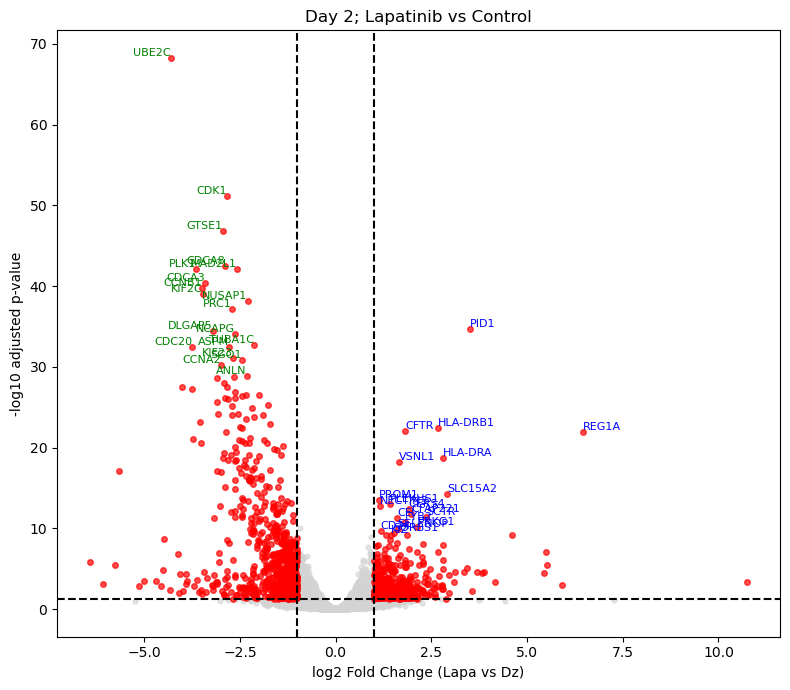

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

df = res.copy()
df = df.dropna(subset=["log2FoldChange", "padj"])
df["-log10padj"] = -np.log10(df["padj"])

# ----- define significance (optional) -----
sig = (df["padj"] < 0.05) & (df["log2FoldChange"].abs() > 1)

# ---- select top 20 up-regulated genes ----
top_up = (
    df[df["log2FoldChange"] > 0]
    .sort_values("padj")
    .head(20)
)

# ---- select top 20 down-regulated genes ----
top_down = (
    df[df["log2FoldChange"] < 0]
    .sort_values("padj")
    .head(20)
)

plt.figure(figsize=(8,7))

# ---- plot non-significant ----
plt.scatter(
    df.loc[~sig, "log2FoldChange"],
    df.loc[~sig, "-log10padj"],
    color="lightgray",
    alpha=0.6,
    s=12,
)

# ---- plot significant ----
plt.scatter(
    df.loc[sig, "log2FoldChange"],
    df.loc[sig, "-log10padj"],
    color="red",
    alpha=0.7,
    s=16,
)

# ---- threshold lines ----
plt.axhline(-np.log10(0.05), linestyle="--", color="black")
plt.axvline(1, linestyle="--", color="black")
plt.axvline(-1, linestyle="--", color="black")

# ---- label top up-regulated ----
for gene, row in top_up.iterrows():
    x, y = row["log2FoldChange"], row["-log10padj"]
    plt.text(
        x,
        y,
        gene,
        fontsize=8,
        color="blue",
        ha="left",
        va="bottom"
    )

# ---- label top down-regulated ----
for gene, row in top_down.iterrows():
    x, y = row["log2FoldChange"], row["-log10padj"]
    plt.text(
        x,
        y,
        gene,
        fontsize=8,
        color="green",
        ha="right",
        va="bottom"
    )

plt.xlabel("log2 Fold Change (Lapa vs Dz)")
plt.ylabel("-log10 adjusted p-value")
plt.title("Day 2; Lapatinib vs Control")
plt.tight_layout()
plt.show()
